In [1]:
import csv
import math
import os
import shutil

import matplotlib as mpl
import matplotlib.pyplot as plt


In [4]:
path = "results_bettinggame_summary.csv"  # single input file
outdir = "plots"
title = "Experiment MCTS.1 - Betting Game"  # optional title override


In [5]:
has_latex = shutil.which("latex") is not None

rc_params = {
    "text.usetex": has_latex,
    "font.family": "serif",

    # Embed fonts as TrueType (selectable/searchable)
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # sizes (tune if you want)
    "axes.titlesize": 23,
    "axes.labelsize": 18,
    "legend.fontsize": 14,
    "legend.title_fontsize": 14,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
}

if has_latex:
    rc_params["text.latex.preamble"] = r"""
        \usepackage{newtxtext}
        \usepackage{newtxmath}
    """
else:
    rc_params["mathtext.fontset"] = "stix"
    rc_params["font.serif"] = ["STIX Two Text", "Times New Roman", "DejaVu Serif"]

mpl.rcParams.update(rc_params)


In [6]:
rows = []
with open(path, "r", newline="") as f:
    reader = csv.DictReader(f)
    required = {
        "env",
        "algorithm",
        "trial",
        "mc_mean",
        "mc_stddev",
        "cvar_regret",
        "optimal_action_prob",
        "catastrophic_count",
    }
    missing = required - set(reader.fieldnames or [])
    if missing:
        raise ValueError(f"{path}: missing columns: {missing}")
    for r in reader:
        rows.append({
            "env": r["env"],
            "algorithm": r["algorithm"],
            "trial": int(r["trial"]),
            "mc_mean": float(r["mc_mean"]),
            "mc_stddev": float(r["mc_stddev"]),
            "cvar_regret": float(r["cvar_regret"]),
            "optimal_action_prob": float(r["optimal_action_prob"]),
            "catastrophic_count": float(r["catastrophic_count"]),
        })


In [7]:
algos = ["UCT", "CATSO", "PATSO"]
colors = ["#1f77b4", "#d62728", "#9467bd"]


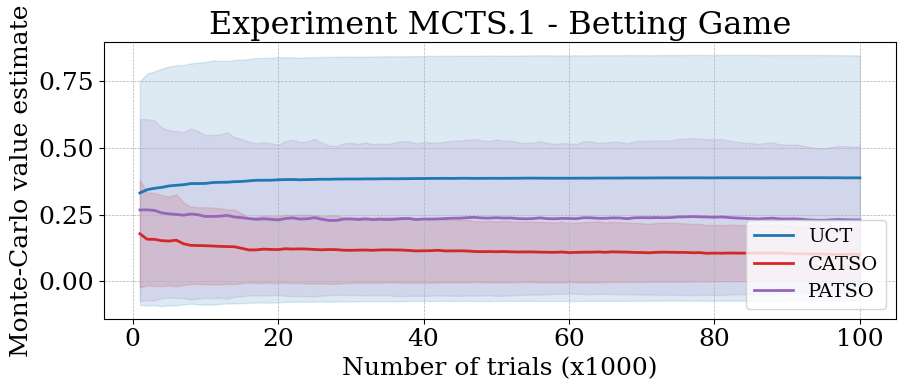

Plot saved to plots/bettinggame.pdf


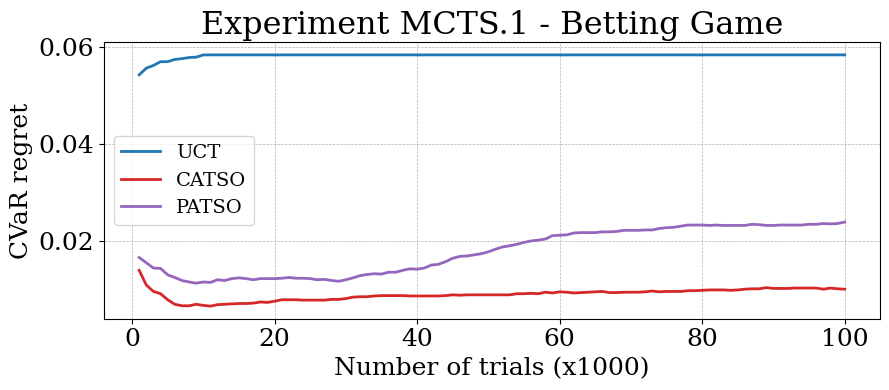

Plot saved to plots/bettinggame_cvar_regret.pdf


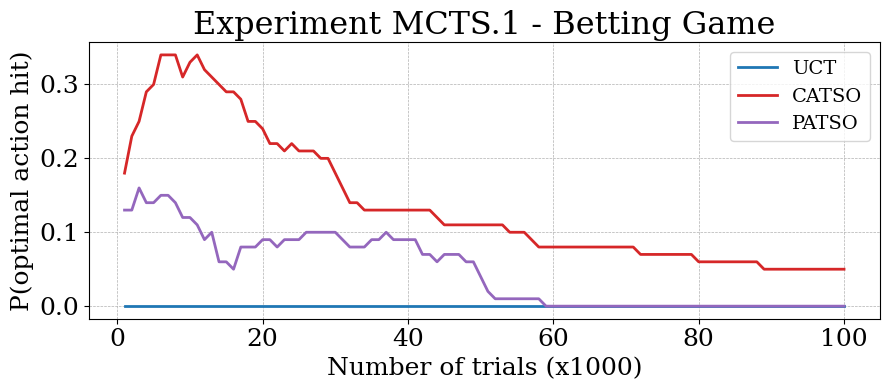

Plot saved to plots/bettinggame_optimal_action_prob.pdf


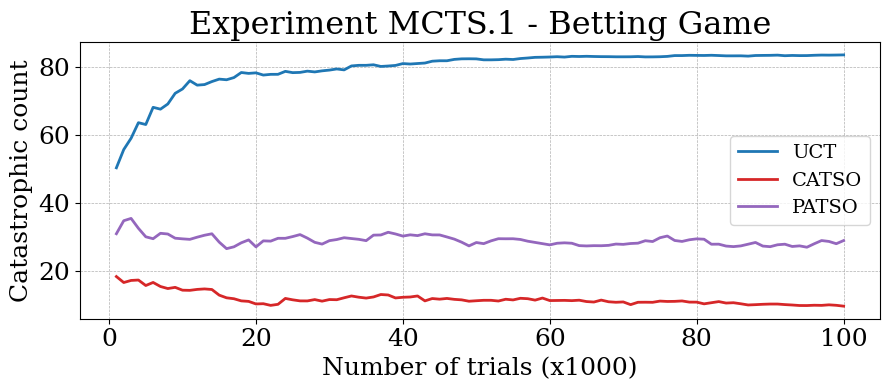

Plot saved to plots/bettinggame_catastrophic_count.pdf


In [8]:
os.makedirs(outdir, exist_ok=True)

env_name = rows[0]["env"]

def metric_rows(alg):
    return sorted((r for r in rows if r["algorithm"] == alg), key=lambda r: r["trial"])

def save_plot(metric, ylabel, suffix, legend_loc="best", with_band=False):
    fig, ax = plt.subplots(figsize=(9, 4))

    for alg, color in zip(algos, colors):
        alg_rows = metric_rows(alg)
        xs = [r["trial"] / 1000.0 for r in alg_rows]
        ys = [r[metric] for r in alg_rows]

        ax.plot(xs, ys, linewidth=2.0, label=alg, color=color)

        if with_band:
            yerr = [r["mc_stddev"] for r in alg_rows]
            lower = [y - e for y, e in zip(ys, yerr)]
            upper = [y + e for y, e in zip(ys, yerr)]
            ax.fill_between(xs, lower, upper, alpha=0.15, color=color)

    ax.set_xlabel("Number of trials (x1000)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.legend(loc=legend_loc, frameon=True, framealpha=0.8)

    out_path = os.path.join(outdir, f"{env_name}{suffix}.pdf")
    fig.tight_layout()
    fig.savefig(out_path)
    plt.show()
    print(f"Plot saved to {out_path}")

save_plot("mc_mean", "Monte-Carlo value estimate", "", legend_loc="lower right", with_band=True)
save_plot("cvar_regret", "CVaR regret", "_cvar_regret")
save_plot("optimal_action_prob", "P(optimal action hit)", "_optimal_action_prob")
save_plot("catastrophic_count", "Catastrophic count", "_catastrophic_count")
